In [274]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util, exposure
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel, gaussian
from skimage.measure import label,  regionprops_table, regionprops,  moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation, remove_small_holes , erosion, closing, skeletonize, binary_closing, disk
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line
from skimage.filters import gaussian, threshold_otsu, threshold_sauvola, frangi, sato, threshold_yen, threshold_triangle, threshold_mean, threshold_li, threshold_minimum
from skimage import util
from liffile import LifFile
import napari
import warnings
warnings.filterwarnings("ignore")

from skimage.graph import route_through_array




In [2]:
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6")
lif_files = list(folder.glob("*.lif"))
print(len(lif_files))


2


In [ ]:
# for lif_path in lif_files:
#     lif_name = "".join(os.path.basename(lif_path).lower().replace(".lif", "")).replace(".", "_")
#     print(lif_name)
#     with LifFile(lif_path) as lif:
#         number_of_lifs = len(lif.images)
#         print(number_of_lifs)
        
#         # for i in range(number_of_lifs):
#         #     output = segment_and_quantify(i,lif, lif_path, classifier_path)
#         #     all_outputs.append(output)
#         # totals = pd.concat(all_outputs)
#         # totals.to_csv("{}.csv".format(lif_name))
#         test = lif_files[0]

day5_exp6


In [150]:
lif_path = lif_files[1]
image_index = 0

dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[0]
    print("shape:", img.shape)


    # Often available:
    print("dims:", getattr(img, "dims", None))
    print("n_frames:", getattr(img, "n_frames", None))
    print("n_channels:", getattr(img, "n_channels", None))
    print("n_z", getattr(img, "n_z", None))
    print(f"Opened image {image_index}, {lif_files[image_index]}")
    img = img.asarray()
dextran_t0 = img[0, dextran_channel, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)

shape: (4, 3, 41, 512, 512)
dims: ('T', 'C', 'Z', 'Y', 'X')
n_frames: None
n_channels: None
n_z None
Opened image 0, Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6\Day5_Exp6.lif
dextran_t0 shape: (41, 512, 512)


In [171]:
def find_best_left_right_route(mask, edge_margin=8, step_cost = 100.0 ):
    H, W = mask.shape

    # Candidate endpoints in left/right margin bands
    left_band  = mask[:, :edge_margin]
    right_band = mask[:, W-edge_margin:]

    left_pts  = list(map(tuple, np.argwhere(left_band)))           # (y, x_in_band)
    left_pts  = [(y, x) for (y, x) in left_pts]                    # x already absolute in band
    right_pts = list(map(tuple, np.argwhere(right_band)))          # (y, x_in_band)
    right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]   # convert to absolute x

    # If we didn't get endpoints (mask slightly short), do a tiny dilation and retry
    if (len(left_pts) == 0) or (len(right_pts) == 0):
        print("extra dilation")
        m2 = binary_dilation(mask, disk(2))
        left_band  = m2[:, :edge_margin]
        right_band = m2[:, W-edge_margin:]
        left_pts  = list(map(tuple, np.argwhere(left_band)))
        right_pts = list(map(tuple, np.argwhere(right_band)))
        right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]
    else:
        m2 = mask

    # Cost: prefer skeleton, penalize background.
    # Use m2 (possibly dilated) to allow bridging tiny edge gaps without changing the skeleton itself.
    # always pay this per pixel step (length penalty)
    off_penalty = step_cost * 10 # or 10
    cost = np.where(m2, step_cost, step_cost + off_penalty).astype(np.float32)

    # Cheap reduction of endpoints to avoid O(N^2) blow-up if bands are dense:
    # sample a subset if too many candidates
    max_candidates = 3
    if len(left_pts) > max_candidates:
        left_pts = [left_pts[i] for i in np.linspace(0, len(left_pts)-1, max_candidates).astype(int)]
    if len(right_pts) > max_candidates:
        right_pts = [right_pts[i] for i in np.linspace(0, len(right_pts)-1, max_candidates).astype(int)]

    best_score = np.inf
    best_path = None


    for s in left_pts:
        for t in right_pts:
            path, c = route_through_array(cost, s, t, fully_connected=True)
            path_len = len(path)


            off_count = sum(not m2[y, x] for (y, x) in path)
            score = path_len + 50 * off_count # increase 50→200 to force staying on m2


            if score < best_score:
                best_score = score
                best_path = path

    path_mask = np.zeros_like(mask, dtype=bool)
    if best_path is not None:
        for y, x in best_path:
            path_mask[y, x] = True
        return path_mask
    else:
        print("No path found (even with margin/dilation). Try increasing edge_margin or lowering bg_penalty.")
        return None
    
    

In [175]:
from skimage.filters import threshold_isodata
def find_ridge_through_plane(img_slice, to_plot=True):
    img_s = gaussian(img_slice, sigma=2)
    img_s = exposure.equalize_adapthist(img_s, clip_limit=0.01)
    
    ridge = sato(img_s, sigmas=np.linspace(2, 8, 10), black_ridges=True)
    ridge = exposure.rescale_intensity(ridge)
    thr = threshold_otsu(ridge)
    bw = ridge > thr
    bw = binary_closing(bw, footprint=disk(9))
    skel = skeletonize(bw)
    lab = label(skel)
    if lab.max() > 0:
        props = regionprops(lab)
        props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
        # keep top three (or fewer if <3 exist)
        labels_to_keep = [p.label for p in props_sorted[:3]]
        skel_main = np.isin(lab, labels_to_keep)
    else:
        skel_main = skel

    path_mask = find_best_left_right_route(skel_main)
    if path_mask is None:
        path_mask = find_best_left_right_route(skel)


    if to_plot == True:
        fig, ax = plt.subplots(ncols=5, figsize=(10, 4))
        ax[0].imshow(img_slice, cmap="gray")
        ax[1].imshow(ridge, cmap="gray")
        ax[2].imshow(bw, cmap="gray")
        ax[3].imshow(img_slice, cmap="gray")
        ys, xs = np.nonzero(skel_main)
        ax[3].scatter(xs, ys, s=1)
        ax[4].imshow(img_slice, cmap="gray")
        y, x = np.nonzero(path_mask)
        ax[4].scatter(x, y, s=1, c="red")
        for a in ax:
            a.axis("off")
        plt.tight_layout()
        plt.show()
    return ridge

In [169]:
lif_path = lif_files[1]
image_index = 2

dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[image_index]
    print("shape:", img.shape)


    # Often available:
    print("dims:", getattr(img, "dims", None))
    print("n_frames:", getattr(img, "n_frames", None))
    print("n_channels:", getattr(img, "n_channels", None))
    print("n_z", getattr(img, "n_z", None))
    print(f"Opened image {image_index}")
    img = img.asarray()
dextran_t0 = img[0, dextran_channel, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)

shape: (4, 3, 41, 512, 512)
dims: ('T', 'C', 'Z', 'Y', 'X')
n_frames: None
n_channels: None
n_z None
Opened image 2
dextran_t0 shape: (41, 512, 512)


In [288]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import median
from skimage.filters import gaussian, threshold_otsu, sobel_v
from skimage import exposure
from skimage.morphology import binary_closing, disk, remove_small_objects, skeletonize, binary_dilation, binary_erosion
from skimage.measure import label, regionprops
from skimage.graph import route_through_array
from skimage.filters import sato


def find_best_left_right_route(mask, edge_margin=8, step_cost=100.0):
    H, W = mask.shape

    # Candidate endpoints in left/right margin bands
    left_band  = mask[:, :edge_margin]
    right_band = mask[:, W-edge_margin:]

    left_pts  = list(map(tuple, np.argwhere(left_band)))
    right_pts = list(map(tuple, np.argwhere(right_band)))
    right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]

    # If we didn't get endpoints (mask slightly short), do a tiny dilation and retry
    if (len(left_pts) == 0) or (len(right_pts) == 0):
        m2 = binary_dilation(mask, disk(2))
        left_band  = m2[:, :edge_margin]
        right_band = m2[:, W-edge_margin:]
        left_pts  = list(map(tuple, np.argwhere(left_band)))
        right_pts = list(map(tuple, np.argwhere(right_band)))
        right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]
    else:
        m2 = mask

    # Cost: prefer mask, penalize background (allows tiny gaps via m2 dilation)
    off_penalty = step_cost * 0.2 # try 0.05–0.5
    cost = np.where(m2, step_cost, step_cost + off_penalty).astype(np.float32)

    # Cheap reduction of endpoints to avoid O(N^2)
    max_candidates = 50
    if len(left_pts) > max_candidates:
        left_pts = [left_pts[i] for i in np.linspace(0, len(left_pts)-1, max_candidates).astype(int)]
    if len(right_pts) > max_candidates:
        right_pts = [right_pts[i] for i in np.linspace(0, len(right_pts)-1, max_candidates).astype(int)]

    best_score = np.inf
    best_path = None

    for s in left_pts:
        for t in right_pts:
            path, _c = route_through_array(cost, s, t, fully_connected=True)
            path_len = len(path)

            off_count = sum(not m2[y, x] for (y, x) in path)
            score = path_len + 200 * off_count  # heavier penalty to stay on m2

            if score < best_score:
                best_score = score
                best_path = path

    path_mask = np.zeros_like(mask, dtype=bool)
    if best_path is not None:
        for y, x in best_path:
            path_mask[y, x] = True
        return path_mask
    else:
        return None


def vertical_brightness_ratio(img, split=0.5, eps=1e-6, robust=True):
    """
    Measures brightness discontinuity top vs bottom.
    Returns absolute log ratio: abs(log(top/bottom)).
    """
    H = img.shape[0]
    y = int(H * split)
    top = img[:y]
    bot = img[y:]

    if robust:
        a = np.median(top)
        b = np.median(bot)
    else:
        a = top.mean()
        b = bot.mean()

    return float(abs(np.log((a + eps) / (b + eps))))


def find_ridge_through_plane(img_slice, to_plot=True, ratio_cutoff=0.4):
    """
    Drop-in replacement:
    - check vertical brightness ratio
    - if high difference -> edge-based boundary detection (sobel_v)
    - else -> ridge detection (sato)
    Returns the response image used (edge or ridge) for debugging.
    """

    # img_s = gaussian(img_slice, sigma=2)
    # img_s = exposure.equalize_adapthist(img_s, clip_limit=0.01)

    # # Gate: decide edge-mode vs ridge-mode
    vr = vertical_brightness_ratio(img_slice, split=0.5, robust=True)
    mode = "edge" if vr > ratio_cutoff else "ridge"
    print(f"Vertical brightness ratio = {vr}")



    # if mode == "edge":
    #     img_med = median(img_slice, disk(7))
    #     thr = threshold_li(img_med)
    #     bw = img_med > thr
    #     bw = remove_small_objects(bw, min_size=1000)
    #     bw = remove_small_holes(bw, area_threshold = 5000)
    #     labels = label(bw)
    #     if labels.max() > 0:
    #         props = regionprops(labels)
    #         biggest = max(props, key=lambda p: p.area)
    #         bw = (labels == biggest.label)
    
    if mode == "edge":
        H, W = img_slice.shape


        def extract_boundary(img, thr_func):
            bw_orig = img > thr_func(img)
            bw = remove_small_objects(bw_orig, min_size=100)
            bw = remove_small_holes(bw, area_threshold=500)


            labels = label(bw)
            if labels.max() > 0:
                props = regionprops(labels)
                biggest = max(props, key=lambda p: p.area)
                bw = (labels == biggest.label)


            # interface line
            path_mask = bw ^ binary_erosion(bw, disk(1))
            return path_mask, bw, bw_orig


        # --- First attempt: Li ---
        img_med = median(img_slice, disk(7))
        path_mask, bw, bw_orig = extract_boundary(img_med, threshold_li)
        title = "li"


        # --- Sanity check: boundary too long? ---
        if path_mask.sum() > 2 * W:
            print("path too long")
            title = "otsu"
            path_mask, bw, bw_orig = extract_boundary(img_med, threshold_minimum)
        
    
    
    
    
    
        if to_plot:
            fig, ax = plt.subplots(ncols=3, figsize=(6, 3))
            ax[0].imshow(img_slice, cmap="gray")
            ax[0].set_title("input")
            ax[1].imshow(bw, cmap="gray")
            ax[1].set_title(title)
            ax[2].imshow(img_slice, cmap="gray")
            ax[2].set_title("skel_main")
            if path_mask is not None:
                y, x = np.nonzero(path_mask)
                ax[2].scatter(x, y, s=2, c="red")
            for a in ax:
                a.axis("off")
                
        

    else: ####### ridge mode 
        img_med = median(img_slice, disk(7))
        resp = sato(img_med, sigmas=np.linspace(2, 8, 10), black_ridges=True)
        resp = exposure.rescale_intensity(resp)
        thr = threshold_yen(resp)
        bw = resp > thr
        bw = binary_closing(bw, footprint=disk(9))
        bw = remove_small_objects(bw, min_size=600)
        skel = skeletonize(bw)
        lab = label(skel)
        if lab.max() > 0:
            props = regionprops(lab)
            props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
            labels_to_keep = [p.label for p in props_sorted[:3]]
            skel_main = np.isin(lab, labels_to_keep)
        else:
            skel_main = skel

        path_mask = find_best_left_right_route(skel_main)
        if path_mask is None:
            path_mask = find_best_left_right_route(skel)

        if to_plot:
            fig, ax = plt.subplots(ncols=3, figsize=(6, 3))
            ax[0].imshow(img_slice, cmap="gray")
            ax[0].set_title("input")
            ax[1].imshow(bw, cmap="gray")
            ax[1].set_title("bw")
            # ax[2].imshow(img_slice, cmap="gray")
            # ax[2].set_title("skel_main")
            # ys, xs = np.nonzero(skel_main)
            # ax[2].scatter(xs, ys, s=1, c="lime")

            ax[2].imshow(img_slice, cmap="gray")
            ax[2].set_title("path")
            if path_mask is not None:
                y, x = np.nonzero(path_mask)
                ax[2].scatter(x, y, s=2, c="red")
            for a in ax:
                a.axis("off")
        plt.suptitle(f"Mode:{mode}")

        plt.tight_layout()
        plt.show()

    # return path_mask, mode, vr, img_med

shape: (4, 3, 41, 512, 512)
dims: ('T', 'C', 'Z', 'Y', 'X')
n_frames: None
n_channels: None
n_z None
Opened image 4
dextran_t0 shape: (41, 512, 512)
Vertical brightness ratio = 0.47000362347650476
path too long
Vertical brightness ratio = 0.5935173318935344
Vertical brightness ratio = 0.7323678833286114
Vertical brightness ratio = 0.8377283967642156
Vertical brightness ratio = 1.1284652313186825
Vertical brightness ratio = 1.1284652313186825
Vertical brightness ratio = 1.2139231117467613
Vertical brightness ratio = 1.2829159808527604
Vertical brightness ratio = 1.3570239502592296


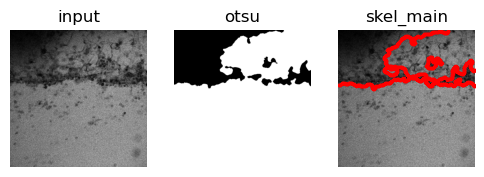

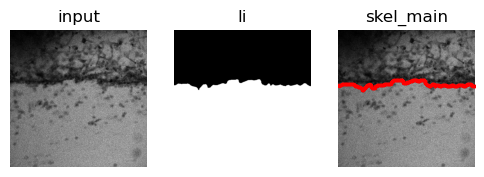

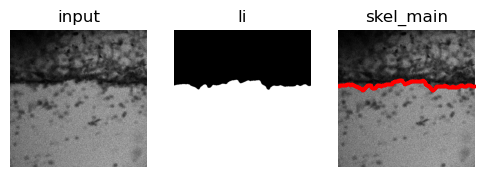

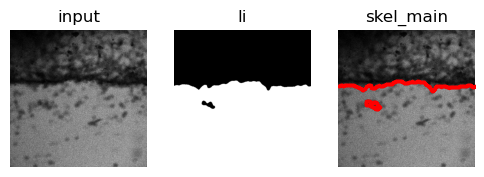

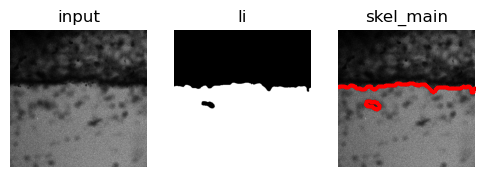

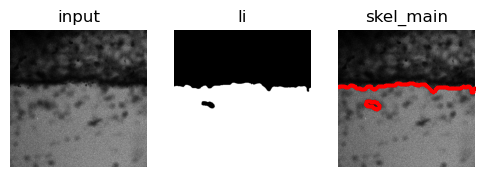

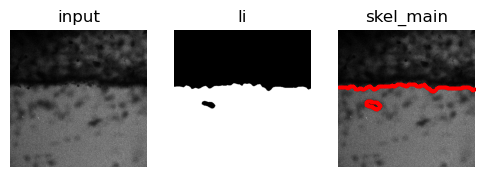

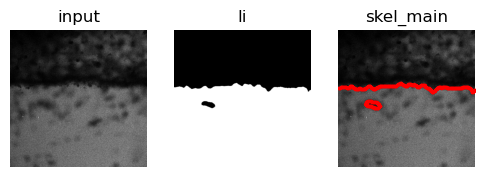

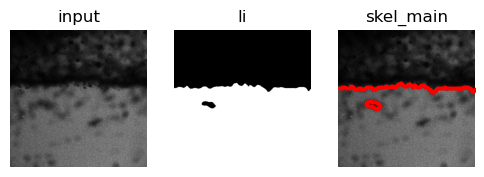

In [291]:
lif_path = lif_files[1]
image_index = 4

dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[image_index]
    print("shape:", img.shape)


    # Often available:
    print("dims:", getattr(img, "dims", None))
    print("n_frames:", getattr(img, "n_frames", None))
    print("n_channels:", getattr(img, "n_channels", None))
    print("n_z", getattr(img, "n_z", None))
    print(f"Opened image {image_index}")
    img = img.asarray()
dextran_t0 = img[0, dextran_channel, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)


for z in [12,15,18,20,25,25,27,28,29]:
    find_ridge_through_plane(dextran_t0[z, :, :], to_plot=True)

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


(<Figure size 800x500 with 8 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Isodata'}>,
        <Axes: title={'center': 'Li'}>, <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Minimum'}>,
        <Axes: title={'center': 'Otsu'}>,
        <Axes: title={'center': 'Triangle'}>,
        <Axes: title={'center': 'Yen'}>], dtype=object))

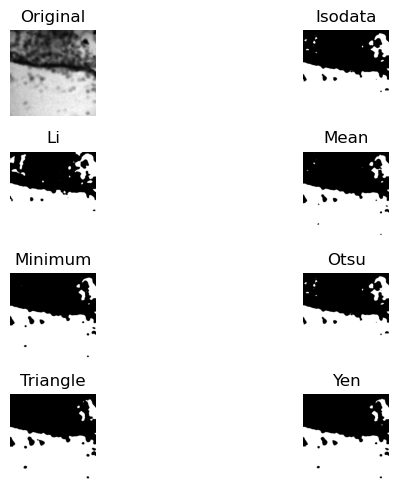

In [254]:
from skimage.filters import try_all_threshold
try_all_threshold(img_med)